In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_classification

In [3]:
?make_classification

Signature:
make_classification(
    n_samples=100,
    n_features=20,
    *,
    n_informative=2,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=None,
    flip_y=0.01,
    class_sep=1.0,
    hypercube=True,
    shift=0.0,
    scale=1.0,
    shuffle=True,
    random_state=None,
)
Docstring:
Generate a random n-class classification problem.

This initially creates clusters of points normally distributed (std=1)
about vertices of an ``n_informative``-dimensional hypercube with sides of
length ``2*class_sep`` and assigns an equal number of clusters to each
class. It introduces interdependence between these features and adds
various types of further noise to the data.

Without shuffling, ``X`` horizontally stacks features in the following
order: the primary ``n_informative`` features, followed by ``n_redundant``
linear combinations of the informative features, followed by ``n_repeated``
duplicates, drawn randomly with replacement from the infor

In [4]:
def make_data(sep):

    X, y = make_classification(n_samples=1000,
                               n_features=2,
                               n_redundant=0,
                               n_clusters_per_class=1,
                               weights=[0.99],
                               class_sep=sep,
                               random_state=0)
    
    X = pd.DataFrame(data=X, columns=['varA', 'varB'])
    y = pd.Series(y)

    return X, y

In [5]:
import imblearn.under_sampling

In [6]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [7]:
from imblearn.under_sampling import OneSidedSelection

In [8]:
?OneSidedSelection

Init signature:
OneSidedSelection(
    *,
    sampling_strategy='auto',
    random_state=None,
    n_neighbors=None,
    n_seeds_S=1,
    n_jobs=None,
)
Docstring:     
Class to perform under-sampling based on one-sided selection method.

Read more in the :ref:`User Guide <condensed_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all classes;

        ``'auto'``: equivalent to ``'not minority'``.

    - When ``list``, the list contains the classes targeted by the
      resampling.

    - When callable, function t

In [10]:
X, y = make_data(sep=1)

In [11]:
oss = OneSidedSelection(sampling_strategy='auto',
                        random_state=0,
                        n_neighbors=1,
                        n_jobs=-1)

X_resampled, y_resampled = oss.fit_resample(X, y)

In [12]:
X.shape, X_resampled.shape

((1000, 2), (772, 2))

In [13]:
dir(plt)

['AbstractContextManager',
 'Annotation',
 'Arrow',
 'Artist',
 'AutoLocator',
 'AxLine',
 'Axes',
 'BackendFilter',
 'Button',
 'Circle',
 'Colorizer',
 'ColorizingArtist',
 'Colormap',
 'Enum',
 'ExitStack',
 'Figure',
 'FigureBase',
 'FigureCanvasBase',
 'FigureManagerBase',
 'FixedFormatter',
 'FixedLocator',
 'FormatStrFormatter',
 'Formatter',
 'FuncFormatter',
 'GridSpec',
 'IndexLocator',
 'Line2D',
 'LinearLocator',
 'Locator',
 'LogFormatter',
 'LogFormatterExponent',
 'LogFormatterMathtext',
 'LogLocator',
 'MaxNLocator',
 'MouseButton',
 'MultipleLocator',
 'Normalize',
 'NullFormatter',
 'NullLocator',
 'PolarAxes',
 'Polygon',
 'Rectangle',
 'ScalarFormatter',
 'Slider',
 'Subplot',
 'SubplotSpec',
 'TYPE_CHECKING',
 'Text',
 'TickHelper',
 'Widget',
 '_ColorizerInterface',
 '_NO_PYPLOT_NOTE',
 '_REPL_DISPLAYHOOK',
 '_ReplDisplayHook',
 '__annotations__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_a

<Axes: xlabel='varA', ylabel='varB'>

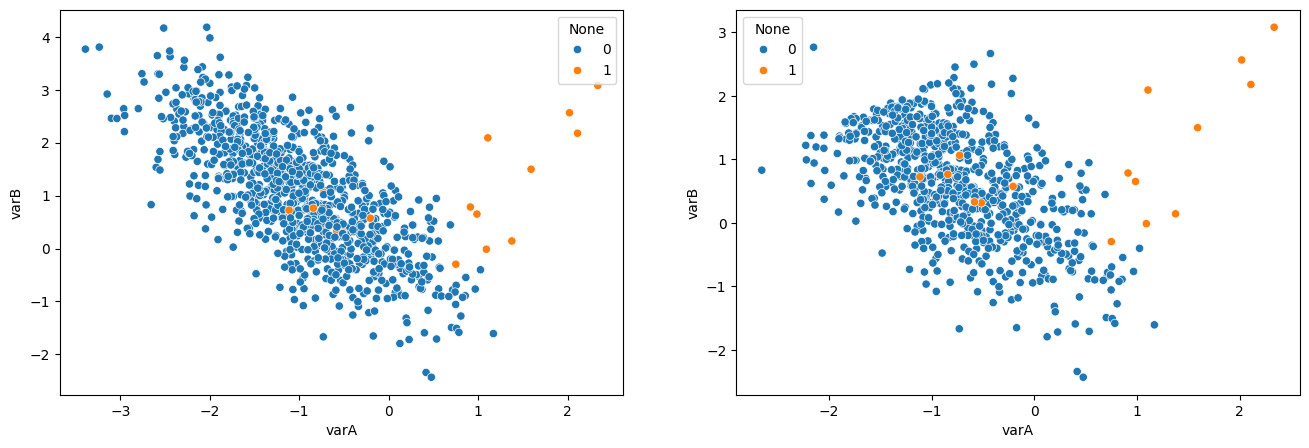

In [ ]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.scatterplot(x='varA', y='varB', data=X, hue=y)

plt.subplot(122)
sns.scatterplot(x='varA', y='varB', data=X_resampled, hue=y_resampled)

In [16]:
df = pd.read_csv('../kdd2004.csv')
df.head()

,0,1,2,3,4,5,6,7,8,9,...,65,66,67,68,69,70,71,72,73,target
0,52.0,32.69,0.30,2.5,20.0,1256.8,-0.89,0.33,11.0,-55.0,...,1595.1,-1.64,2.83,-2.0,-50.0,445.2,-0.35,0.26,0.76,-1
1,58.0,33.33,0.00,16.5,9.5,608.1,0.50,0.07,20.5,-52.5,...,762.9,0.29,0.82,-3.0,-35.0,140.3,1.16,0.39,0.73,-1
2,77.0,27.27,-0.91,6.0,58.5,1623.6,-1.40,0.02,-6.5,-48.0,...,1491.8,0.32,-1.29,0.0,-34.0,658.2,-0.76,0.26,0.24,-1
3,41.0,27.91,-0.35,3.0,46.0,1921.6,-1.36,-0.47,-32.0,-51.5,...,2047.7,-0.98,1.53,0.0,-49.0,554.2,-0.83,0.39,0.73,-1
4,50.0,28.00,-1.32,-9.0,12.0,464.8,0.88,0.19,8.0,-51.5,...,479.5,0.68,-0.59,2.0,-36.0,-6.9,2.02,0.14,-0.23,-1


In [17]:
df.target.value_counts(normalize=True)

target
-1    0.991108
 1    0.008892
Name: proportion, dtype: float64

In [18]:
df.target = df.target.map({-1:0, 1:1})
df.target.value_counts()

target
0    144455
1      1296
Name: count, dtype: int64

In [19]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [20]:
?OneSidedSelection

Init signature:
OneSidedSelection(
    *,
    sampling_strategy='auto',
    random_state=None,
    n_neighbors=None,
    n_seeds_S=1,
    n_jobs=None,
)
Docstring:     
Class to perform under-sampling based on one-sided selection method.

Read more in the :ref:`User Guide <condensed_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all classes;

        ``'auto'``: equivalent to ``'not minority'``.

    - When ``list``, the list contains the classes targeted by the
      resampling.

    - When callable, function t

In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [23]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df.target, test_size=0.3, random_state=0)
X_train.shape, X_test.shape

((102025, 74), (43726, 74))

In [24]:
oss = OneSidedSelection(
    sampling_strategy='auto',
    random_state=0,
    n_neighbors=1,
    n_jobs=-1
)
X_resampled, y_resampled = oss.fit_resample(X_train, y_train)

In [25]:
X_train.shape, X_resampled.shape

((102025, 74), (101769, 74))

In [26]:
y_train.value_counts()

target
0    101134
1       891
Name: count, dtype: int64

In [28]:
y_resampled.value_counts()

target
0    100878
1       891
Name: count, dtype: int64

# Plotting the data

<Axes: xlabel='0', ylabel='1'>

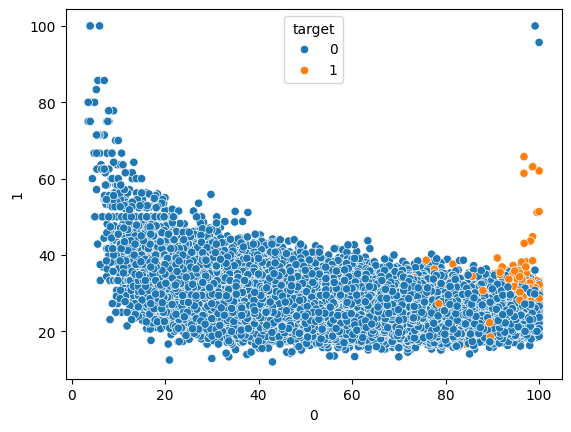

In [30]:
sns.scatterplot(data=X_train, x='0', y='1', hue=y_train)

<Axes: xlabel='0', ylabel='1'>

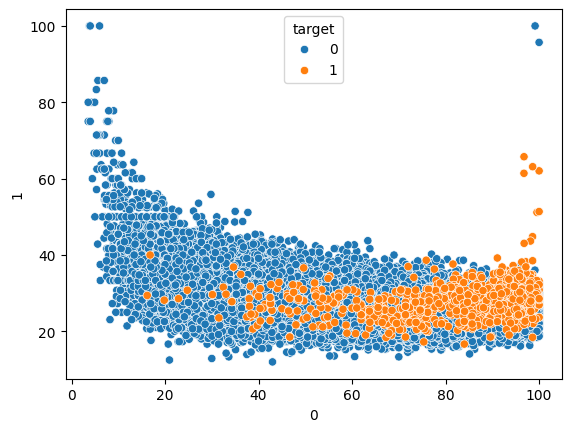

In [31]:
sns.scatterplot(data=X_resampled, x='0', y='1', hue=y_resampled)

<Axes: xlabel='4', ylabel='5'>

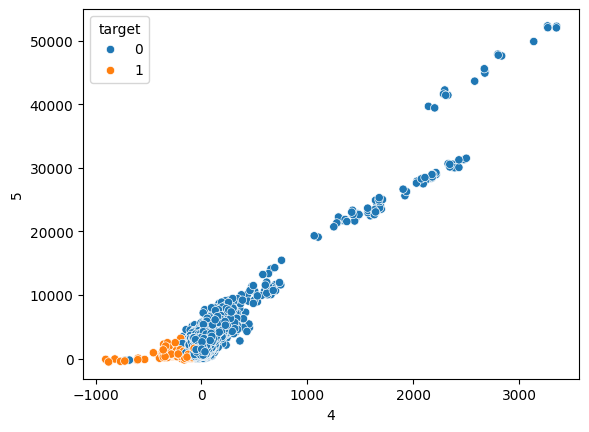

In [32]:
sns.scatterplot(data=X_train, x='4', y='5', hue=y_train)

<Axes: xlabel='4', ylabel='5'>

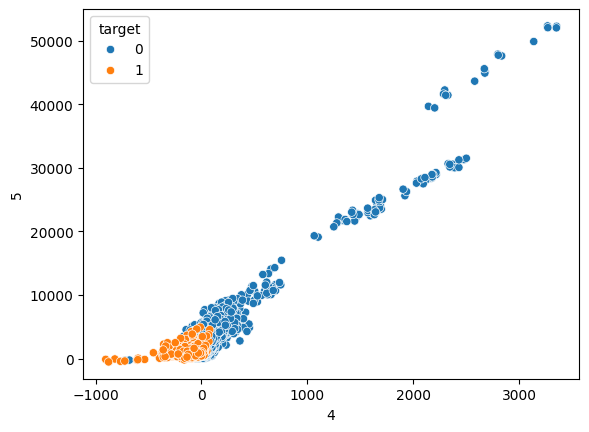

In [33]:
sns.scatterplot(data=X_resampled, x='4', y='5', hue=y_resampled)

In [35]:
help(OneSidedSelection)

Help on class OneSidedSelection in module imblearn.under_sampling._prototype_selection._one_sided_selection:

class OneSidedSelection(imblearn.under_sampling.base.BaseCleaningSampler)
 |  OneSidedSelection(*, sampling_strategy='auto', random_state=None, n_neighbors=None, n_seeds_S=1, n_jobs=None)
 |  
 |  Class to perform under-sampling based on one-sided selection method.
 |  
 |  Read more in the :ref:`User Guide <condensed_nearest_neighbors>`.
 |  
 |  Parameters
 |  ----------
 |  sampling_strategy : str, list or callable
 |      Sampling information to sample the data set.
 |  
 |      - When ``str``, specify the class targeted by the resampling. Note the
 |        the number of samples will not be equal in each. Possible choices
 |        are:
 |  
 |          ``'majority'``: resample only the majority class;
 |  
 |          ``'not minority'``: resample all classes but the minority class;
 |  
 |          ``'not majority'``: resample all classes but the majority class;
 |  
 |  

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
?RandomForestClassifier

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the

In [38]:
import sklearn.metrics

In [39]:
dir(sklearn.metrics)

['ConfusionMatrixDisplay',
 'DetCurveDisplay',
 'DistanceMetric',
 'PrecisionRecallDisplay',
 'PredictionErrorDisplay',
 'RocCurveDisplay',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_base',
 '_classification',
 '_dist_metrics',
 '_pairwise_distances_reduction',
 '_pairwise_fast',
 '_plot',
 '_ranking',
 '_regression',
 '_scorer',
 'accuracy_score',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'auc',
 'average_precision_score',
 'balanced_accuracy_score',
 'brier_score_loss',
 'calinski_harabasz_score',
 'check_scoring',
 'class_likelihood_ratios',
 'classification_report',
 'cluster',
 'cohen_kappa_score',
 'completeness_score',
 'confusion_matrix',
 'consensus_score',
 'coverage_error',
 'd2_absolute_error_score',
 'd2_log_loss_score',
 'd2_pinball_score',
 'd2_tweedie_score',
 'davies_bouldin_score',
 'dcg_score',
 'det_curve',
 'euclidean_distances',
 'explained_variance_sco

In [40]:
from sklearn.metrics import roc_auc_score

In [41]:
def run_randomForests(X_train, X_test, y_train, y_test):
    rf = RandomForestClassifier(n_estimators=200, criterion='entropy', random_state=39, max_depth=4, n_jobs=-1)
    rf.fit(X_train, y_train)

    print('Train set')
    pred = rf.predict_proba(X_train)[:,1]
    print('Random Forests roc-auc: {}'.format(roc_auc_score(y_train, pred)))

    print('Test set')
    pred = rf.predict_proba(X_test)[:,1]
    print('Random Forests roc-auc: {}'.format(roc_auc_score(y_test, pred)))

In [42]:
run_randomForests(X_train, X_test, y_train, y_test)

Train set
Random Forests roc-auc: 0.9867547799202832
Test set
Random Forests roc-auc: 0.9867483651329821


In [43]:
run_randomForests(X_resampled, X_test, y_resampled, y_test)

Train set
Random Forests roc-auc: 0.9867582379791847
Test set
Random Forests roc-auc: 0.9861937343420534
